<font size=5  color= red> 实训：自行车租赁统计数据分析 </font>

In [5]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (10,8))
%matplotlib inline

<Figure size 1000x800 with 0 Axes>

In [6]:
bike = pd.read_csv('../data/bike.csv')
bike.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## 查看有无缺失值

In [7]:
bike.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

## #查看待处理数据的数据类型

In [8]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [9]:
bike.datetime = pd.to_datetime(bike.datetime)
bike.dtypes

datetime      datetime64[ns]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object

In [10]:
bike = bike.set_index('datetime')


## 先从数值型数据入手，可以看出租赁额（count）数值差异大，所以希望观察一下它们的密度分布

sns.distplot(s, bins = 10, hist = True, kde = True,  
          norm_hist = False, rug = True, vertical = False,
            color = ‘g', label = 'distplot', axlabel = 'x')


C:\Users\24138\AppData\Local\Temp\ipykernel_16412\3693449687.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bike["count"])


<Axes: xlabel='count', ylabel='Density'>

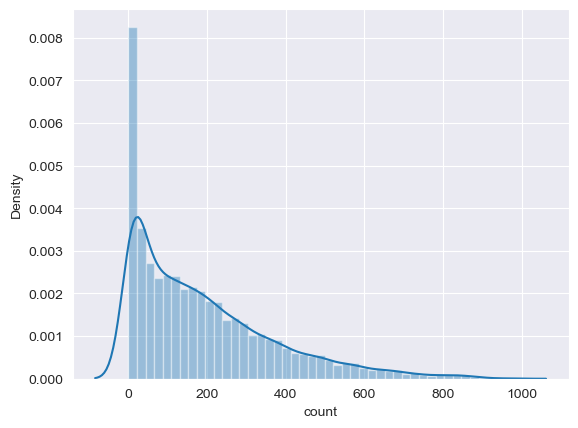

In [11]:
sns.distplot(bike["count"])
# plt.plot(s.index,s.values)#作图


In [12]:

bike["count"].describe()


count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64

C:\Users\24138\AppData\Local\Temp\ipykernel_16412\115850484.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bike1["count"])


<Axes: xlabel='count', ylabel='Density'>

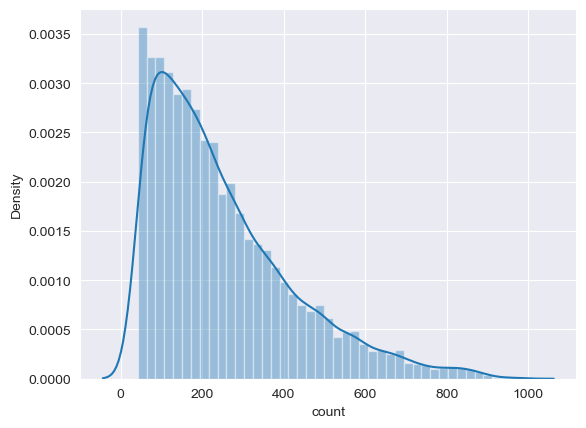

In [13]:
def Count(x):
    if x <42:
        return np.nan
    else:
        return x
bike1 = bike
bike1["count"] = bike1["count"].apply(Count)
bike1 = bike1.dropna(axis=0, how='any')
sns.distplot(bike1["count"])

In [14]:
def Count(x):
    if x <145:
        return np.nan
    else:
        return x
bike2= bike
bike2["count"] = bike2["count"].apply(Count)
bike2 = bike2.dropna(axis=0, how='any')

C:\Users\24138\AppData\Local\Temp\ipykernel_16412\970332326.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bike2["count"])


<Axes: xlabel='count', ylabel='Density'>

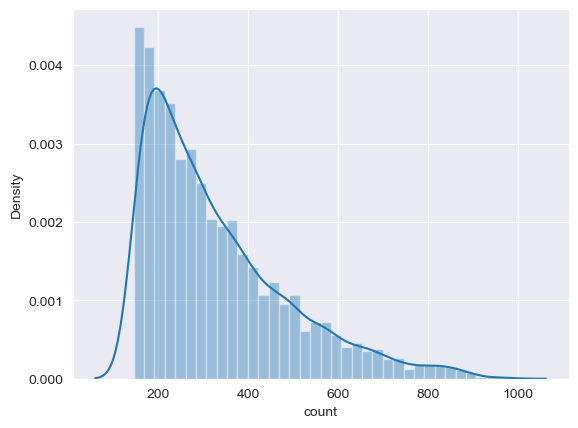

In [15]:
sns.distplot(bike2["count"])
# plt.plot(s.index,s.values)#作图

In [16]:
bike = bike2

In [17]:
bike.shape

(5455, 11)

In [18]:
y_bike = bike.groupby(bike.index.year).mean()['count']
y_bike 

datetime
2011    274.526697
2012    366.408629
Name: count, dtype: float64

<Axes: xlabel='datetime'>

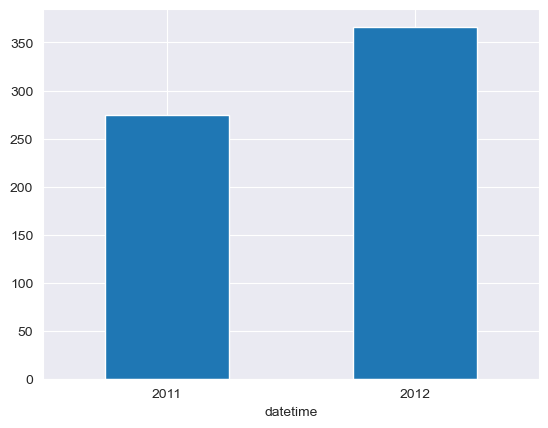

In [19]:
y_bike.plot(kind='bar',rot = 0)


In [20]:
mm_bike = bike.resample('M',kind = "period").mean()
mm_bike.head()


C:\Users\24138\AppData\Local\Temp\ipykernel_16412\3597317424.py:1: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  mm_bike = bike.resample('M',kind = "period").mean()
C:\Users\24138\AppData\Local\Temp\ipykernel_16412\3597317424.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mm_bike = bike.resample('M',kind = "period").mean()


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,,,,,,,,,,,
2011-01,1.0,0.000000,1.000000,1.160000,8.692000,10.909600,49.320000,11.880440,5.280000,175.520000,180.800000
2011-02,1.0,0.000000,0.791045,1.283582,14.294925,17.243134,44.179104,18.179100,23.835821,168.208955,192.044776
2011-03,1.0,0.000000,0.666667,1.291667,16.553750,19.728021,49.458333,18.187778,48.583333,163.781250,212.364583
2011-04,2.0,0.078014,0.617021,1.453901,19.970780,23.634752,55.177305,16.893741,60.624113,177.539007,238.163121
2011-05,2.0,0.000000,0.758197,1.446721,23.060820,27.214037,64.069672,13.946627,55.745902,224.110656,279.856557


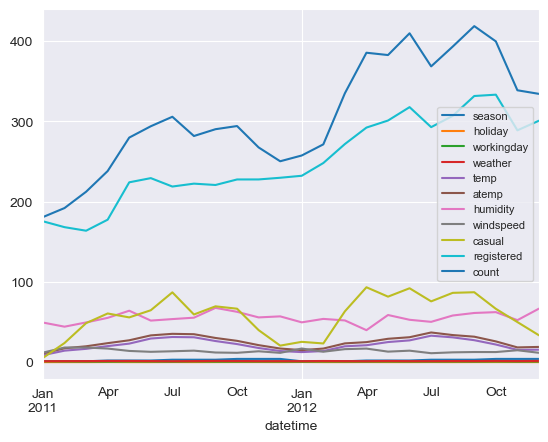

In [21]:
mm_bike.plot()
plt.legend(loc = "best",fontsize = 8)

In [22]:
m_bike = bike.groupby(bike.index.month).mean()['count']
m_bike 

datetime
1     246.528736
2     250.560784
3     301.152738
4     336.355450
5     336.163265
6     355.171329
7     339.714533
8     343.414035
9     363.035849
10    354.840304
11    308.497992
12    300.295045
Name: count, dtype: float64

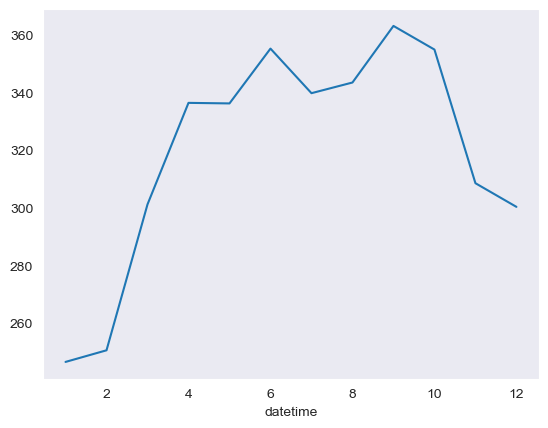

In [23]:
m_bike.plot()
plt.grid()# 9月份达到最大值

In [24]:
h_bike = bike.groupby(bike.index.hour).mean()['count']
h_bike 

datetime
0     175.040000
1     159.666667
6     170.777778
7     332.275194
8     464.194611
9     256.773109
10    247.983051
11    273.677966
12    300.908587
13    306.273504
14    294.686217
15    302.322946
16    358.840314
17    493.831382
18    462.374101
19    361.031746
20    280.290419
21    227.334507
22    197.688776
23    180.289855
Name: count, dtype: float64

In [25]:
h_bike.plot("bar",rot = 0)

TypeError: `Series.plot()` should not be called with positional arguments, only keyword arguments. The order of positional arguments will change in the future. Use `Series.plot(kind='bar')` instead of `Series.plot('bar',)`.

In [ ]:
season_bike = bike.groupby(bike.season).mean()['count']
season_bike 

In [ ]:
season_bike.plot(kind = "bar",rot = 0)

In [ ]:
temp_bike = bike.groupby([bike.temp]).mean()['count']
temp_bike.sample(10)

In [ ]:
temp_bike.plot()

In [ ]:
wind_bike = bike.groupby(bike.windspeed).mean()['count']


In [ ]:
wind_bike.sort_values(ascending=False).sample(10)

In [ ]:
wind_bike_sort = wind_bike.sort_values(ascending=False)
wind_bike_sort.head(20).plot(kind="bar",rot = 60)

In [ ]:
weather_bike = bike.groupby(bike.weather).mean()['count']
weather_bike.plot(kind='bar',rot = 0)